# Exploratory analysis of the Spotify songs dataset

Exploratory data analysis (EDA) of ~2,000 popular songs (1999-2019) and their
Spotify audio features. The goal is to understand **what makes a song popular**
and how the musical attributes relate to one another.

The logic lives in the `src/spotify_analysis/` package (tested functions); this
notebook only orchestrates and visualizes. Questions we answer:

1. Which artists and genres concentrate the most popularity (fairly weighted)?
2. Are explicit songs more popular? (with a statistical test, not just bars)
3. Is there an "optimal" duration?
4. Which attributes correlate with popularity? Can it be *predicted*?
5. How do genres co-occur, and how do the attributes evolve over time?


## 0. Setup and imports

In [1]:
import sys
from pathlib import Path

# Allows importing the local package both locally and on Colab.
SRC = Path("../src")
if SRC.exists():
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

import spotify_analysis as sa
from spotify_analysis import viz

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")

DATA_PATH = Path("../data/songs.csv")

## 1. Load and clean

Raw load, deduplication (exact + artist/song, keeping the most popular version) and the genre-placeholder fix. All encapsulated and logged in `sa.load_raw` / `sa.clean`.

In [2]:
df_raw = sa.load_raw(DATA_PATH)
df = sa.clean(df_raw)
df = sa.add_features(df)      # duration_min, genre_clean, genre_list
df = sa.add_duration_bucket(df)
df.head()

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,...,acousticness,instrumentalness,liveness,valence,tempo,genre,duration_min,genre_clean,genre_list,duration_bucket
0,The Neighbourhood,Sweater Weather,240400,False,2013,89,0.612,0.807,10,-2.810,...,0.04950,0.017700,0.1010,0.398,124.053,"rock, pop",4.006667,"pop, rock","[rock, pop]",3.5-4.5 min
1,Tom Odell,Another Love,244360,True,2013,88,0.445,0.537,4,-8.532,...,0.69500,0.000017,0.0944,0.131,122.769,pop,4.072667,pop,[pop],3.5-4.5 min
2,Eminem,Without Me,290320,True,2002,87,0.908,0.669,7,-2.827,...,0.00286,0.000000,0.2370,0.662,112.238,hip hop,4.838667,hip hop,[hip hop],>4.5 min
3,Billie Eilish,lovely (with Khalid),200185,False,2018,86,0.351,0.296,4,-10.109,...,0.93400,0.000000,0.0950,0.120,115.284,"pop, Dance/Electronic",3.336417,"dance/electronic, pop","[pop, dance/electronic]",2.5-3.5 min
4,Eminem,The Real Slim Shady,284200,True,2000,86,0.949,0.661,5,-4.244,...,0.03020,0.000000,0.0454,0.760,104.504,hip hop,4.736667,hip hop,[hip hop],>4.5 min


## 2. Initial exploratory analysis

Each inspection in its own cell so that **all** outputs are shown (in Jupyter only the last expression of a cell is printed; bundling them hid `describe()`).

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1926 entries, 0 to 1925
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   artist            1926 non-null   str     
 1   song              1926 non-null   str     
 2   duration_ms       1926 non-null   int64   
 3   explicit          1926 non-null   bool    
 4   year              1926 non-null   int64   
 5   popularity        1926 non-null   int64   
 6   danceability      1926 non-null   float64 
 7   energy            1926 non-null   float64 
 8   key               1926 non-null   int64   
 9   loudness          1926 non-null   float64 
 10  mode              1926 non-null   int64   
 11  speechiness       1926 non-null   float64 
 12  acousticness      1926 non-null   float64 
 13  instrumentalness  1926 non-null   float64 
 14  liveness          1926 non-null   float64 
 15  valence           1926 non-null   float64 
 16  tempo             1926 non-null   f

In [4]:
df.describe(include='all')

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,...,acousticness,instrumentalness,liveness,valence,tempo,genre,duration_min,genre_clean,genre_list,duration_bucket
count,1926,1926,1926.000000,1926,1926.000000,1926.000000,1926.000000,1926.000000,1926.000000,1926.000000,...,1926.000000,1926.000000,1926.000000,1926.000000,1926.000000,1926,1926.000000,1926,1926,1926
unique,835,1879,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,59,NaN,52,59,4
top,Rihanna,Sorry,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,pop,NaN,pop,[pop],3.5-4.5 min
freq,23,4,NaN,1393,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,411,NaN,411,411,1055
mean,NaN,NaN,228642.718588,NaN,2009.494808,59.838525,0.667918,0.721907,5.367601,-5.510202,...,0.128452,0.015491,0.181835,0.553345,120.163474,NaN,3.810712,NaN,NaN,NaN
std,NaN,NaN,39297.197196,NaN,5.879546,21.322152,0.140295,0.153144,3.618117,1.942893,...,0.172948,0.088705,0.141162,0.221172,26.957682,NaN,0.654953,NaN,NaN,NaN
min,NaN,NaN,113000.000000,NaN,1998.000000,0.000000,0.129000,0.054900,0.000000,-20.514000,...,0.000019,0.000000,0.021500,0.038100,60.019000,NaN,1.883333,NaN,NaN,NaN
25%,NaN,NaN,203506.000000,NaN,2004.000000,56.000000,0.581000,0.624250,2.000000,-6.487750,...,0.013525,0.000000,0.088450,0.390000,98.986750,NaN,3.391767,NaN,NaN,NaN
50%,NaN,NaN,223259.500000,NaN,2010.000000,65.000000,0.676500,0.739000,6.000000,-5.279500,...,0.055700,0.000000,0.124000,0.560000,120.028000,NaN,3.720992,NaN,NaN,NaN
75%,NaN,NaN,248036.000000,NaN,2015.000000,73.000000,0.765000,0.841000,8.000000,-4.167250,...,0.176000,0.000070,0.241750,0.732500,134.191750,NaN,4.133933,NaN,NaN,NaN


In [5]:
# Null values per column
df.isnull().sum()

artist              0
song                0
duration_ms         0
explicit            0
year                0
popularity          0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
genre               0
duration_min        0
genre_clean         0
genre_list          0
duration_bucket     0
dtype: int64

## 3. Which artists concentrate the most "engagement"?

We want to combine **mean popularity** and **song volume**, but fairly. A plain
average rewards whoever has a single lucky song; the `mean * log(n)` weighting
(previous version) did the opposite and worse: `log(1)=0` sent every single-song
artist to a **score of zero**, erasing ~59% of the artists from the ranking.

We use a **Bayesian shrinkage estimator** (IMDB Top-250 style): each mean is
pulled toward the global mean in proportion to how little data supports it.
Every artist gets a finite, comparable score.

In [6]:
artist_scores = sa.bayesian_weighted_score(df, "artist")
artist_scores.head(10)

,artist,n_songs,mean_value,score
0,The Neighbourhood,2,87.000000,77.946175
1,Billie Eilish,4,82.000000,77.567705
2,XXXTENTACION,4,81.500000,77.167705
3,Bruno Mars,11,77.545455,76.069877
4,Twenty One Pilots,3,81.000000,75.709631
5,Tom Odell,1,88.000000,73.919263
6,Marshmello,6,75.833333,73.548361
7,Coldplay,11,74.363636,73.153210
8,Red Hot Chili Peppers,6,75.166667,72.976932
9,Arctic Monkeys,5,75.600000,72.973088


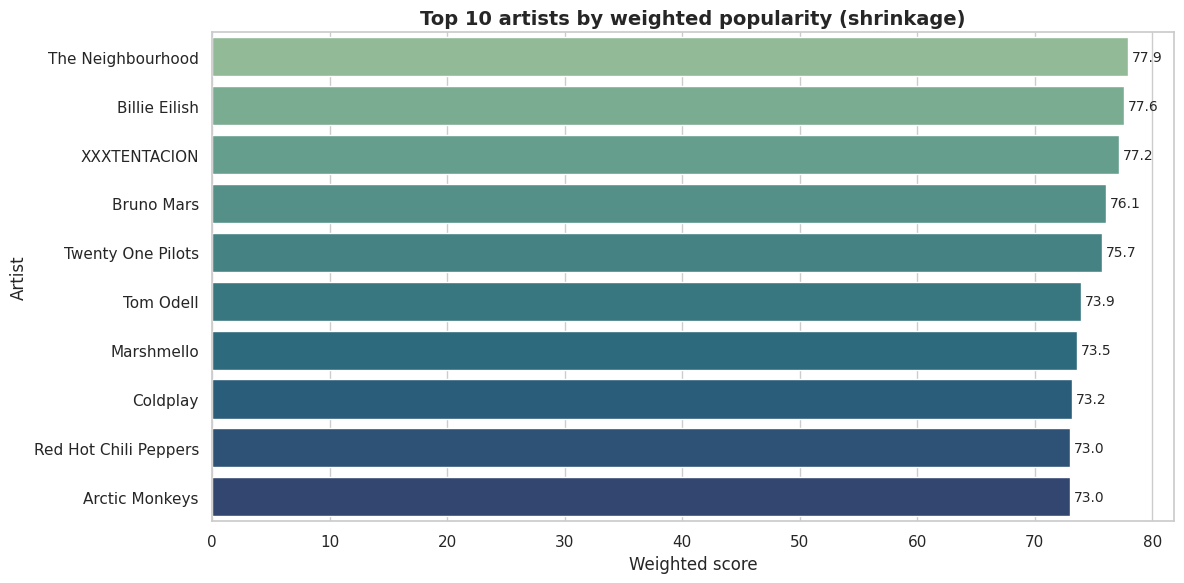

In [7]:
top10 = artist_scores.head(10)
viz.barh_ranked(
    top10, x="score", y="artist",
    title="Top 10 artists by weighted popularity (shrinkage)",
    xlabel="Weighted score",
)
plt.show()

## 4. "Premium" genres: popularity vs volume

Same estimator as for artists (methodological consistency: this cell previously
used `log1p` while the artist cell used `log`).

In [8]:
genre_scores = sa.bayesian_weighted_score(df, "genre_clean")
genre_scores.head(10)

,genre_clean,n_songs,mean_value,score
0,"metal, rock",36,70.527778,69.580629
1,metal,9,72.000000,68.594787
2,"folk/acoustic, pop, rock",4,74.250000,67.524645
3,rock,57,66.754386,66.354295
4,"dance/electronic, pop, r&b",6,67.333333,64.572088
5,hip hop,120,64.241667,64.116881
6,"country, pop",8,65.875000,64.037812
7,"hip hop, pop",265,64.086792,64.031415
8,"dance/electronic, metal, pop, rock",1,76.000000,63.429964
9,"hip hop, latin, pop",14,63.785714,62.996277


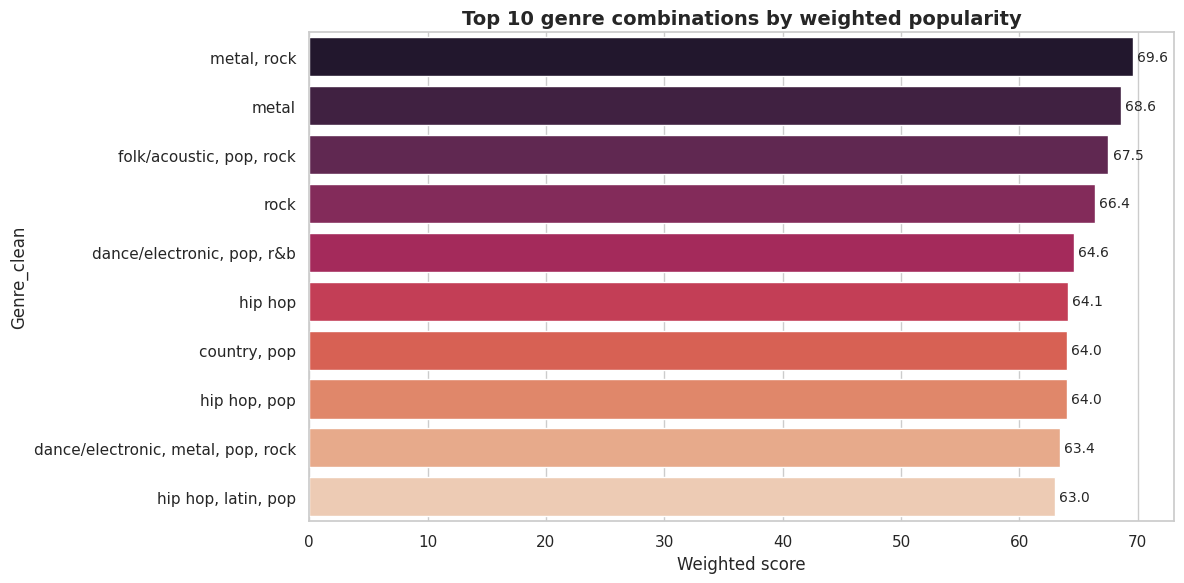

In [9]:
top10_g = genre_scores.head(10)
viz.barh_ranked(
    top10_g, x="score", y="genre_clean",
    title="Top 10 genre combinations by weighted popularity",
    xlabel="Weighted score", palette="rocket",
)
plt.show()

## 5. Explicit vs non-explicit: is there a real difference?

Comparing the heights of two bars doesn't tell you whether the difference is
signal or noise. We run a **Mann-Whitney test** (no normality assumption), report
the **effect size** (rank-biserial) and a **95% bootstrap CI** for the difference
in means.

In [10]:
res = sa.compare_explicit(df)
for k, v in res.items():
    print(f"{k:>28}: {round(v, 4) if isinstance(v, float) else v}")

               mean_explicit: 61.4278
           mean_non_explicit: 59.2304
                  n_explicit: 533
              n_non_explicit: 1393
                 u_statistic: 399976.0
                     p_value: 0.0085
   effect_size_rank_biserial: -0.0774
               diff_ci95_low: 0.0426
              diff_ci95_high: 4.2815


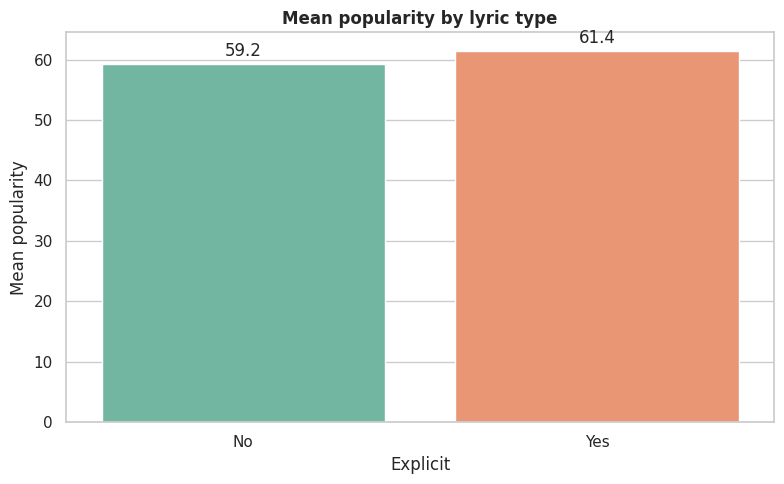

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
means = pd.DataFrame({
    "explicit": ["No", "Yes"],
    "mean_popularity": [res["mean_non_explicit"], res["mean_explicit"]],
})
sns.barplot(data=means, x="explicit", y="mean_popularity",
            hue="explicit", palette="Set2", legend=False, ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", padding=3)
ax.set_title("Mean popularity by lyric type", weight="bold")
ax.set_xlabel("Explicit"); ax.set_ylabel("Mean popularity")
plt.tight_layout(); plt.show()

> **Reading.** The difference is statistically significant (p < 0.01) but the
> effect is **small**: explicit songs are only ~2 points more popular on average,
> with an effect size close to zero. Significant is not the same as important —
> with ~1,900 songs, even tiny differences come out "significant".

## 6. Is there an optimal duration?

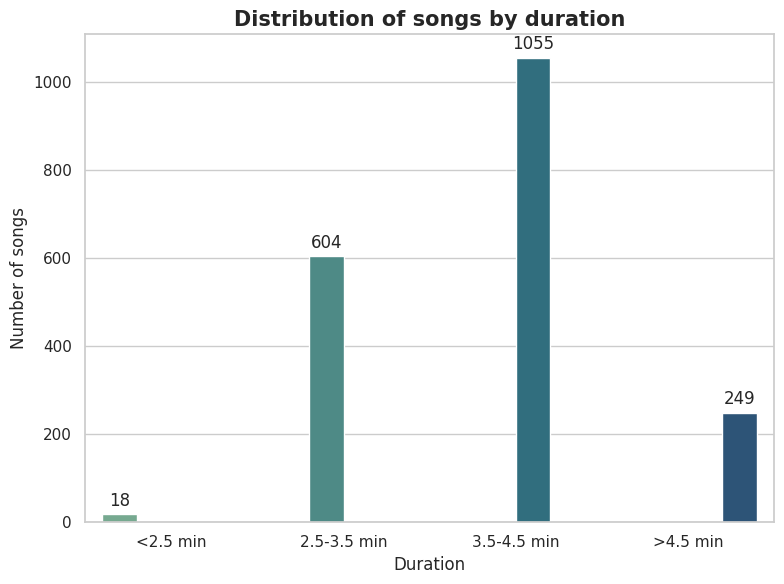

In [12]:
dur_counts = df["duration_bucket"].value_counts().sort_index()
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=dur_counts.index, y=dur_counts.values,
                 hue=dur_counts.index, palette="crest", legend=False)
ax.set_title("Distribution of songs by duration", fontsize=15, weight="bold")
ax.set_xlabel("Duration"); ax.set_ylabel("Number of songs")
for c in ax.containers:
    ax.bar_label(c, padding=3)
plt.tight_layout(); plt.show()

## 7. Attribute correlations, and can popularity be *predicted*?

First the correlation map; then the hard test: train models and measure R^2 with
honest cross-validation.

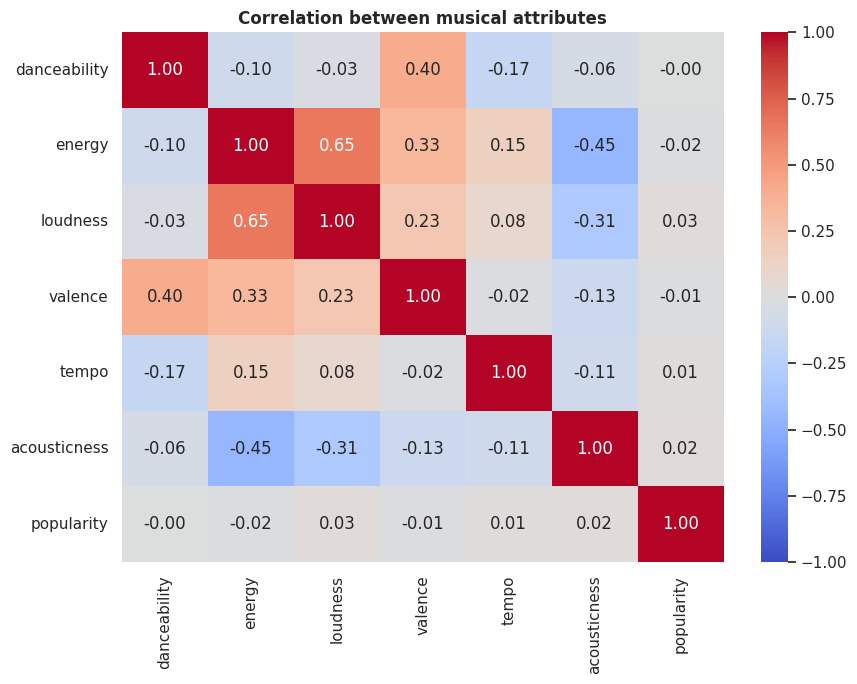

In [13]:
corr = df[["danceability", "energy", "loudness", "valence", "tempo",
           "acousticness", "popularity"]].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation between musical attributes", weight="bold")
plt.tight_layout(); plt.show()

In [14]:
r2_table = sa.popularity_predictability(df, sa.AUDIO_FEATURES)
r2_table

,model,r2_mean,r2_std
0,LinearRegression,-0.004686,0.007785
1,RandomForest,-0.056993,0.038111


> **Reading.** No attribute correlates strongly with popularity, and a full
> model (linear or Random Forest) yields **R^2 close to 0** under shuffled CV.
> In other words: **audio features do not predict popularity**. This is a finding,
> not a failure — popularity is driven by external factors (marketing, the artist,
> playlists) not present in these columns.
>
> Technical note: we use `KFold(shuffle=True)` on purpose. The df ends up sorted
> by popularity after cleaning, and without shuffling the folds leak the target's
> structure, yielding absurdly negative R^2.

## 8. Interactive genre co-occurrence network

In [15]:
pair_counts = sa.genre_cooccurrence(df)
print(f"{len(pair_counts)} genre pairs. Most common: {pair_counts.most_common(1)}")
fig = viz.build_cooccurrence_figure(pair_counts, min_weight=2)
fig.show()

38 genre pairs. Most common: [(('hip hop', 'pop'), 604)]


## 9. Evolution of musical attributes over time

Yearly means, normalized to [0,1] only to compare trends on a common scale.

In [16]:
features = ["danceability", "energy", "acousticness", "valence",
            "tempo", "loudness", "speechiness", "instrumentalness"]
df_yearly = df.groupby("year")[features].mean().reset_index()
df_yearly[features] = MinMaxScaler().fit_transform(df_yearly[features])
df_melted = df_yearly.melt(id_vars="year", value_vars=features,
                           var_name="feature", value_name="norm_value")

import plotly.express as px
fig = px.line(df_melted, x="year", y="norm_value", color="feature",
              title="Evolution of musical attributes (normalized) 1999-2019")
fig.show()

## 10. Conclusions

- **Artists/genres.** With a fair shrinkage score, the ranking rewards sustained
  popularity without erasing single-song artists.
- **Explicit.** Significant difference but small effect (~2 points).
- **Prediction.** Audio features do **not** predict popularity (R^2 ~ 0).
  Popularity lives outside these features.
- **Genres.** `hip hop`+`pop` is the dominant co-occurrence; rock anchors the network.